# Sensitivity and Measurement

I examine how duration, return accounting, yield sampling, and parameter choices
affect the portfolio estimates. I hold the primary NSA/EWM specification fixed
and vary one assumption at a time.

The primary data come from the 2026-09-28 snapshot. Separate public GS10/DGS10
inputs dated 2026-10-01 support the US yield-sampling check. Both contain
current-vintage data at retrieval. This notebook runs from those saved inputs.

In [1]:
import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter

from inflation_base_effects.data import REPO_ROOT, load_cpi, load_yields
from inflation_base_effects.portfolio import compute_bond_returns, mod_duration
from inflation_base_effects.research import (
    comparison_table,
    constraint_summary,
    evaluation_conventions,
    performance_summary,
    realized_turnover,
    run_experiment,
    sensitivity_experiments,
)

pd.options.display.float_format = "{:.4f}".format
plt.style.use("seaborn-v0_8-whitegrid")
FIGURES = Path(REPO_ROOT) / "docs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
headline_nsa = load_cpi()
yields_monthly = load_yields()
baseline = run_experiment(headline_nsa, yields_monthly)
display(
    performance_summary(baseline.returns, realized_turnover(baseline.holdings)).to_frame("primary")
)

,primary
N,400.0000
ann_return,-0.0008
ann_vol,0.0275
return_to_vol,-0.0276
NW t-stat,-0.1756
NW p-value,0.8606
CI 95% lower,-0.0092
CI 95% upper,0.0077
NW maxlags,5.0000
max_additive_drawdown,-0.1822


## 1. Duration across yields

I use the modified-duration formula for a par bond with semiannual coupons:

$$D(y)=\frac{1-(1+y/2)^{-2T}}{y},\qquad D(0)=T.$$

Here $y$ is the decimal annual yield and $T=10$ years. I evaluate the formula
with `log1p` and `expm1` to avoid cancellation near zero, and leave missing
yields missing. The table shows its behaviour across negative, zero, and
positive yields. Unit tests compare positive-yield values with an independent
cash-flow calculation.

The negative-yield extension is an algebraic par-bond approximation. Actual
negative-yielding instruments can have different coupons and durations.

In [2]:
yield_grid = np.array([-1, -0.5, -0.001, 0, 0.001, 0.099999, 0.1, 0.100001, 1, 5])
duration_by_yield = pd.DataFrame(
    {
        "yield_pct": yield_grid,
        "modified_duration": [mod_duration(y) for y in yield_grid],
    }
).set_index("yield_pct")
with pd.option_context("display.float_format", "{:.6f}".format):
    display(duration_by_yield)

,modified_duration
yield_pct,
-1.000000,10.544817
-0.500000,10.267383
-0.001000,10.000525
0.000000,10.000000
0.001000,9.999475
0.099999,9.947692
0.100000,9.947692
0.100001,9.947691
1.000000,9.493710


## 2. Return timing and sample coverage

I hold portfolio weights fixed and compare three accounting conventions:
prior-period holdings with complete cases, prior-period holdings with missing
contributions set to zero, and contemporaneous holdings. The last case is
noncausal because formation inputs include information from the earning month.
It measures the distortion from that timing error.

Zero filling can admit months without a prior position or a required asset
return. I show both available-history and common-date estimates, followed by
the primary result over the full sample and from 2010 onward.

The implementation delay moves calendar labels by one month. This preserves
the final eligible signal when a country's input history ends before the
available return history, while still truncating signals at the last return date.

In [3]:
evaluation_cases = evaluation_conventions(baseline.holdings, yields_monthly)
display(comparison_table(evaluation_cases, common=False))
display(comparison_table(evaluation_cases, common=True))
sample_cases = {
    "Full available primary": baseline.returns,
    "Fixed 2010 onward": baseline.returns.loc["2010-01-01":],
}
display(comparison_table(sample_cases, common=False))

,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
"Prior holdings, complete cases",400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-09,2024-12
"Prior holdings, missing contributions zero",401.0000,-0.0008,0.0275,-0.0275,-0.1757,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-08,2024-12
Contemporaneous holdings (NONCAUSAL),401.0000,0.0065,0.0265,0.2468,1.3229,0.1859,-0.0032,0.0163,5.0000,-0.1585,NaN,1991-08,2024-12


,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
"Prior holdings, complete cases",400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-09,2024-12
"Prior holdings, missing contributions zero",400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-09,2024-12
Contemporaneous holdings (NONCAUSAL),400.0000,0.0063,0.0265,0.2388,1.2760,0.2020,-0.0034,0.0161,5.0000,-0.1585,NaN,1991-09,2024-12


,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
Full available primary,400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-09,2024-12
Fixed 2010 onward,180.0000,0.0020,0.0270,0.0756,0.2985,0.7653,-0.0113,0.0154,4.0000,-0.0810,NaN,2010-01,2024-12


## 3. US yield sampling

GS10 averages business-day yields. I use the last available DGS10 observation
in each completed month to construct a month-end series, without interpolating
holidays. Both series supply yields for the same return approximation.

I compare a US long-only proxy and the US contribution of fixed primary
holdings on common dates. I then substitute the month-end US series in the
four-country optimizer, holding all other inputs and rules constant. This
isolates the effect of US sampling within a panel whose other countries still
use monthly averages.

Sources are [GS10](https://fred.stlouisfed.org/series/GS10) and
[DGS10](https://fred.stlouisfed.org/series/DGS10). The supplementary manifest
records retrieval URLs, time, and SHA-256 checksums. I first check agreement
between the GS10 observations in the two snapshots.

In [4]:
supplement = Path(REPO_ROOT) / "data/supplementary/2026-10-01"
manifest = json.loads((supplement / "manifest.json").read_text())
for name, expected in manifest["sha256"].items():
    assert hashlib.sha256((supplement / name).read_bytes()).hexdigest() == expected
average = pd.read_csv(supplement / "GS10.csv", index_col=0, parse_dates=True).iloc[:, 0]
daily = pd.read_csv(supplement / "DGS10.csv", index_col=0, parse_dates=True).iloc[:, 0]
month_end = daily.resample("MS").last()
# Only months completed before the supplementary snapshot date are eligible.
completed = pd.Timestamp("2026-10-01")
month_end = month_end.loc[month_end.index < completed]
average = average.loc[average.index < completed]
us_column = "B_USA_BD"
vintage_check = pd.concat(
    {"baseline": yields_monthly[us_column], "supplement": average}, axis=1
).dropna()
display(
    pd.Series(
        {
            "overlap_months": len(vintage_check),
            "max_GS10_difference_pp": (vintage_check.baseline - vintage_check.supplement)
            .abs()
            .max(),
        }
    )
)
average_ret, _ = compute_bond_returns(average.to_frame(us_column))
end_ret, _ = compute_bond_returns(month_end.to_frame(us_column))
us_returns = pd.concat(
    {"Monthly-average proxy": average_ret[us_column], "Month-end proxy": end_ret[us_column]}, axis=1
).dropna()
us_returns = us_returns.loc[baseline.returns.index.min() : baseline.returns.index.max()]
display(comparison_table(dict(us_returns.items())))
display(us_returns.corr())
prior_us_h = baseline.holdings[us_column].shift(1).reindex(us_returns.index)
display(comparison_table({name: series * prior_us_h for name, series in us_returns.items()}))
mixed_yields = yields_monthly.copy()
mixed_yields[us_column] = month_end.reindex(mixed_yields.index)
mixed_experiment = run_experiment(headline_nsa, mixed_yields)
display(
    comparison_table(
        {
            "Primary monthly averages": baseline.returns,
            "US month-end only (mixed diagnostic)": mixed_experiment.returns,
        }
    )
)

overlap_months           440.0000
max_GS10_difference_pp     0.0000
dtype: float64

,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
Monthly-average proxy,400.0000,0.0472,0.0631,0.7477,3.5831,0.0003,0.0214,0.0730,5.0000,-0.2933,NaN,1991-09,2024-12
Month-end proxy,400.0000,0.0459,0.0754,0.6084,3.3827,0.0007,0.0193,0.0725,5.0000,-0.3075,NaN,1991-09,2024-12


,Monthly-average proxy,Month-end proxy
Monthly-average proxy,1.0000,0.7220
Month-end proxy,0.7220,1.0000


,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
Monthly-average proxy,400.0000,-0.0066,0.0314,-0.2106,-1.1627,0.2450,-0.0177,0.0045,5.0000,-0.2955,NaN,1991-09,2024-12
Month-end proxy,400.0000,-0.0115,0.0371,-0.3093,-1.7910,0.0733,-0.0240,0.0011,5.0000,-0.4577,NaN,1991-09,2024-12


,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
Primary monthly averages,400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-09,2024-12
US month-end only (mixed diagnostic),400.0000,-0.0045,0.0358,-0.1270,-0.8472,0.3969,-0.0151,0.0060,5.0000,-0.3015,NaN,1991-09,2024-12


Using month-end US yields gives approximately -0.45% annual portfolio return,
compared with -0.08% using monthly averages throughout. This sensitivity concerns
measurement as well as portfolio formation: the optimizer also responds to the
different covariance estimates.

The other countries retain monthly-average yields, and both versions of the
US return proxy omit instrument-specific cash flows and trading costs. These
comparisons therefore leave executable return measurement unresolved.

## 4. Parameter sensitivity

| Parameter | Values | Primary setting |
|---|---|---|
| EWM score half-life | 3, 6, 12 months | 6 |
| Assumed IC | 0.01, 0.025, 0.05, 0.10 | 0.05 |
| Implementation delay | 1, 2, 3 months | 1 |
| Covariance half-lives | (6,18), (12,36), (24,72) | (12,36) |

I vary one parameter at a time, retaining the 0.7/0.3 covariance blend and all
portfolio constraints. Each parameter family uses common dates; different
warm-up requirements can leave different samples across families.

I report every value in the grid. The intervals and p-values are nominal and
do not adjust for multiple comparisons. These checks use the same historical
data as the primary test and supply descriptive sensitivity evidence.

In [5]:
families = sensitivity_experiments(headline_nsa, yields_monthly, baseline=baseline)
sensitivity_tables = {}
for family, variants in families.items():
    sensitivity_tables[family] = comparison_table(
        {label: experiment.returns for label, experiment in variants.items()},
        {label: experiment.holdings for label, experiment in variants.items()},
    )
sensitivity = pd.concat(sensitivity_tables, names=["family", "value"])
display(sensitivity)
display(
    pd.concat(
        {
            family: pd.DataFrame(
                {label: constraint_summary(exp.diagnostics) for label, exp in variants.items()}
            ).T
            for family, variants in families.items()
        },
        names=["family", "value"],
    )
)

N ann_return ann_vol return_to_vol  \
family               value                                                
Smoothing            3        394.0000    -0.0006  0.0265       -0.0223   
                     6        394.0000    -0.0010  0.0273       -0.0350   
                     12       394.0000    -0.0013  0.0272       -0.0466   
Assumed IC           0.01     400.0000    -0.0016  0.0243       -0.0665   
                     0.025    400.0000    -0.0009  0.0263       -0.0360   
                     0.05     400.0000    -0.0008  0.0275       -0.0276   
                     0.1      400.0000    -0.0004  0.0280       -0.0160   
Implementation delay 1        398.0000    -0.0007  0.0276       -0.0244   
                     2        398.0000     0.0035  0.0276        0.1282   
                     3        398.0000    -0.0029  0.0270       -0.1087   
Covariance           (6, 18)  395.0000    -0.0013  0.0273       -0.0466   
                     (12, 36) 395.0000    -0.0002  0.0276       -0.0063   
                     (24, 72) 395.0000     0.0000  0.0277        0.0005   

                              NW t-stat NW p-value CI 95% lower CI 95% upper  \
family               value                                                     
Smoothing            3          -0.1367     0.8913      -0.0091       0.0079   
                     6          -0.2217     0.8246      -0.0094       0.0075   
                     12         -0.2893     0.7724      -0.0099       0.0073   
Assumed IC           0.01       -0.4273     0.6692      -0.0090       0.0058   
                     0.025      -0.2287     0.8191      -0.0091       0.0072   
                     0.05       -0.1756     0.8606      -0.0092       0.0077   
                     0.1        -0.1031     0.9179      -0.0089       0.0081   
Implementation delay 1          -0.1554     0.8765      -0.0092       0.0078   
                     2           0.7798     0.4355      -0.0054       0.0125   
                     3          -0.5834     0.5597      -0.0128       0.0069   
Covariance           (6, 18)    -0.2835     0.7768      -0.0101       0.0075   
                     (12, 36)   -0.0395     0.9685      -0.0088       0.0085   
                     (24, 72)    0.0031     0.9975      -0.0086       0.0087   

                              NW maxlags max_additive_drawdown  \
family               value                                       
Smoothing            3            5.0000               -0.2094   
                     6            5.0000               -0.1822   
                     12           5.0000               -0.1668   
Assumed IC           0.01         5.0000               -0.1427   
                     0.025        5.0000               -0.1613   
                     0.05         5.0000               -0.1822   
                     0.1          5.0000               -0.1777   
Implementation delay 1            5.0000               -0.1822   
                     2            5.0000               -0.1025   
                     3            5.0000               -0.1873   
Covariance           (6, 18)      5.0000               -0.2133   
                     (12, 36)     5.0000               -0.1822   
                     (24, 72)     5.0000               -0.1809   

                              mean_monthly_turnover    start      end  
family               value                                             
Smoothing            3                       2.0258  1992-03  2024-12  
                     6                       1.9824  1992-03  2024-12  
                     12                      1.9848  1992-03  2024-12  
Assumed IC           0.01                    1.9309  1991-09  2024-12  
                     0.025                   1.9571  1991-09  2024-12  
                     0.05                    1.9805  1991-09  2024-12  
                     0.1                     1.9822  1991-09  2024-12  
Implementation delay 1                       1.9806  1991-11  2024-12  

months  failed  max_duration_residual  \
family               value                                              
Smoothing            3        404.0000  0.0000                 0.0000   
                     6        401.0000  0.0000                 0.0000   
                     12       395.0000  0.0000                 0.0000   
Assumed IC           0.01     401.0000  0.0000                 0.0000   
                     0.025    401.0000  0.0000                 0.0000   
                     0.05     401.0000  0.0000                 0.0000   
                     0.1      401.0000  0.0000                 0.0000   
Implementation delay 1        401.0000  0.0000                 0.0000   
                     2        401.0000  0.0000                 0.0000   
                     3        401.0000  0.0000                 0.0000   
Covariance           (6, 18)  401.0000  0.0000                 0.0000   
                     (12, 36) 401.0000  0.0000                 0.0000   
                     (24, 72) 396.0000  0.0000                 0.0000   

                               max_gross  max_position  max_forecast_vol  \
family               value                                                 
Smoothing            3            2.0000        0.5000            0.0552   
                     6            2.0000        0.5000            0.0554   
                     12           2.0000        0.5000            0.0554   
Assumed IC           0.01         2.0000        0.5000            0.0467   
                     0.025        2.0000        0.5000            0.0483   
                     0.05         2.0000        0.5000            0.0554   
                     0.1          2.0000        0.5000            0.0554   
Implementation delay 1            2.0000        0.5000            0.0554   
                     2            1.9998        0.5000            0.0541   
                     3            2.0000        0.5000            0.0530   
Covariance           (6, 18)      2.0000        0.5000            0.0637   
                     (12, 36)     2.0000        0.5000            0.0554   
                     (24, 72)     2.0000        0.5000            0.0435   

                               position_binding_pct  gross_binding_pct  \
family               value                                               
Smoothing            3                      99.7525             2.2277   
                     6                      99.7506             2.2444   
                     12                    100.0000             2.2785   
Assumed IC           0.01                   97.7556             0.9975   
                     0.025                  99.5012             1.9950   
                     0.05                   99.7506             2.2444   
                     0.1                   100.0000             2.7431   
Implementation delay 1                      99.7506             2.2444   
                     2                     100.0000             3.2419   
                     3                     100.0000             2.4938   
Covariance           (6, 18)               100.0000             2.2444   
                     (12, 36)               99.7506             2.2444   
                     (24, 72)              100.0000             2.5253   

                               vol_binding_pct  
family               value                      
Smoothing            3                  0.0000  
                     6                  0.0000  
                     12                 0.0000  
Assumed IC           0.01               0.0000  
                     0.025              0.0000  
                     0.05               0.0000  
                     0.1                0.0000  
Implementation delay 1                  0.0000  
                     2                  0.0000  
                     3                  0.0000  
Covariance           (6, 18)            0.0000  
                     (12, 36)           0.0000 

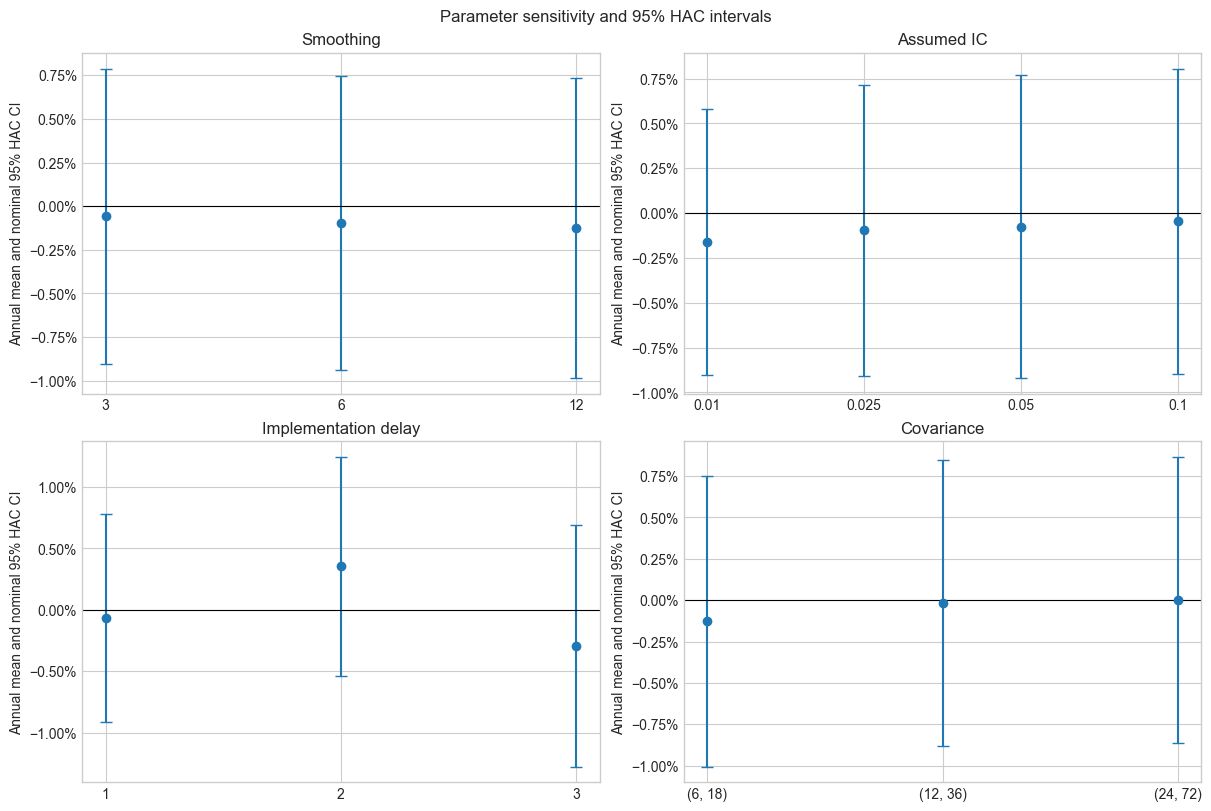

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for ax, (family, table) in zip(axes.flat, sensitivity_tables.items(), strict=True):
    mean = table.ann_return.astype(float)
    lower = table["CI 95% lower"].astype(float)
    upper = table["CI 95% upper"].astype(float)
    ax.errorbar(range(len(table)), mean, yerr=[mean - lower, upper - mean], fmt="o", capsize=4)
    ax.set_xticks(range(len(table)), table.index)
    ax.axhline(0, color="black", lw=0.8)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set(title=family, ylabel="Annual mean and nominal 95% HAC CI")
fig.suptitle("Parameter sensitivity and 95% HAC intervals")
fig.savefig(FIGURES / "parameter_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Inference sensitivity

I keep returns fixed and vary the Newey-West lag length. The automatic lag rule
is the primary convention. The intervals express uncertainty in annual-return
units, allowing comparison with the magnitude of the estimated mean.

In [7]:
display(
    pd.DataFrame(
        {str(lag): performance_summary(baseline.returns, maxlags=lag) for lag in [None, 3, 6, 12]}
    ).T.rename(index={"None": "automatic"})
)
primary_inference = performance_summary(baseline.returns)
print(
    f"Primary annual mean: {primary_inference['ann_return']:.2%}; "
    f"95% HAC interval: [{primary_inference['CI 95% lower']:.2%}, "
    f"{primary_inference['CI 95% upper']:.2%}]."
)

,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
automatic,400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-09,2024-12
3,400.0000,-0.0008,0.0275,-0.0276,-0.1661,0.8681,-0.0097,0.0082,3.0000,-0.1822,NaN,1991-09,2024-12
6,400.0000,-0.0008,0.0275,-0.0276,-0.1792,0.8578,-0.0090,0.0075,6.0000,-0.1822,NaN,1991-09,2024-12
12,400.0000,-0.0008,0.0275,-0.0276,-0.1924,0.8474,-0.0085,0.0070,12.0000,-0.1822,NaN,1991-09,2024-12


Primary annual mean: -0.08%; 95% HAC interval: [-0.92%, 0.77%].


## 6. Measurement limits

The estimates remain imprecise across the parameter and inference checks.
Changing US yield sampling has a larger effect on the point estimate than
several of the parameter changes, while neither sampling convention establishes
positive predictive performance.

A more direct test would use executable bond or futures returns with explicit
financing and FX treatment, together with point-in-time CPI data and release
dates. Independent validation would then test whether any estimated relationship
persists beyond this historical sample.